# Limited-Memory BFGS

## Problem

Newton's method converges quadratically but requires the Hessian; quasi-Newton methods build a
Hessian (or inverse-Hessian) approximation from gradient information alone, recovering superlinear
convergence without ever forming a second derivative. BFGS is the standard quasi-Newton update, but
its inverse-Hessian approximation $H_k$ is a dense $n\times n$ matrix — infeasible to store once
$n$ is in the thousands. L-BFGS (Nocedal 1980; Liu & Nocedal 1989) applies the BFGS
inverse-Hessian-vector product **implicitly**, using only the last $m\ll n$ update pairs, in
$O(mn)$ time and memory instead of $O(n^2)$.

## Method

**The secant condition.** After a step from $x_k$ to $x_{k+1}=x_k+\alpha_k p_k$, define
$s_k=x_{k+1}-x_k$ and $y_k=\nabla f(x_{k+1})-\nabla f(x_k)$. BFGS requires its next Hessian
approximation $B_{k+1}$ to satisfy the **secant equation** $B_{k+1}s_k=y_k$ — the discrete analogue
of the mean value theorem for the gradient along the step just taken — together with symmetry and
(subject to $s_k^\top y_k>0$, guaranteed by a Wolfe line search) positive definiteness.

**The BFGS update.** Among all symmetric matrices satisfying the secant equation, BFGS picks the
one closest to the current $B_k$ in a weighted Frobenius norm, giving the rank-2 update (stated
here directly for the *inverse* Hessian $H_k=B_k^{-1}$, which is what a quasi-Newton step actually
needs, via the Sherman-Morrison-Woodbury identity applied to the rank-2 $B_k$ update):
$$
H_{k+1} = (I-\rho_k s_k y_k^\top)H_k(I-\rho_k y_k s_k^\top) + \rho_k s_k s_k^\top,
\qquad \rho_k = \frac{1}{y_k^\top s_k}.
$$
Applied to a gradient, $H_{k+1}\nabla f(x_{k+1})$ requires only inner products and vector
operations with $s_k,y_k$ — never $H_k$ formed explicitly — which is exactly the leverage L-BFGS
exploits.

**The two-loop recursion.** Unrolling the BFGS update over the last $m$ iterations expresses
$H_k\nabla f(x_k)$ as a sequence of scalar-weighted vector operations on $\{s_i,y_i\}_{i=k-m}^{k-1}$
and an initial (typically diagonal) $H_k^{(0)}=\gamma_k I$, $\gamma_k=s_{k-1}^\top y_{k-1}/y_{k-1}^\top
y_{k-1}$ (a scalar Rayleigh-quotient-type estimate of the curvature along the most recent step,
Nocedal 1980):

```
q = grad f(x_k)
for i = k-1, k-2, ..., k-m:      # backward pass
    alpha_i = rho_i * s_i . q
    q = q - alpha_i * y_i
r = gamma_k * q                  # initial Hessian scaling
for i = k-m, ..., k-2, k-1:      # forward pass
    beta = rho_i * y_i . r
    r = r + (alpha_i - beta) * s_i
# r = H_k * grad f(x_k)
```
This never forms an $n\times n$ matrix: the entire history is $2m$ vectors of length $n$, and the
recursion is $O(mn)$ per gradient evaluation regardless of how large $n$ is.

**Line search.** A backtracking line search enforcing the (weak) Wolfe conditions —
$f(x_k+\alpha p_k)\le f(x_k)+c_1\alpha\nabla f(x_k)^\top p_k$ (sufficient decrease) and
$\nabla f(x_k+\alpha p_k)^\top p_k \ge c_2\nabla f(x_k)^\top p_k$ (curvature) — is used at every
step; the curvature condition is exactly what guarantees $s_k^\top y_k>0$, keeping the implicit
inverse-Hessian positive definite.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(20260721)

plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["grid.color"] = "0.85"
plt.rcParams["grid.linestyle"] = "-"


In [2]:
def rosenbrock(x):
    return np.sum(100.0 * (x[1:] - x[:-1] ** 2) ** 2 + (1.0 - x[:-1]) ** 2)


def rosenbrock_grad(x):
    n = len(x)
    g = np.zeros(n)
    xm = x[1:-1]
    xm_m1 = x[:-2]
    xm_p1 = x[2:]
    g[1:-1] = 200 * (xm - xm_m1 ** 2) - 400 * (xm_p1 - xm ** 2) * xm - 2 * (1 - xm)
    g[0] = -400 * x[0] * (x[1] - x[0] ** 2) - 2 * (1 - x[0])
    g[-1] = 200 * (x[-1] - x[-2] ** 2)
    return g


def backtracking_wolfe(f, grad, x, p, fx, gx, c1=1e-4, c2=0.9, alpha0=1.0, max_ls=50):
    alpha = alpha0
    dg0 = gx @ p
    x_new, f_new, g_new = x, fx, gx
    for _ in range(max_ls):
        x_new = x + alpha * p
        f_new = f(x_new)
        if f_new > fx + c1 * alpha * dg0:
            alpha *= 0.5
            continue
        g_new = grad(x_new)
        if g_new @ p < c2 * dg0:
            alpha *= 1.8
            continue
        return alpha, x_new, f_new, g_new
    return alpha, x_new, f_new, grad(x_new)


def lbfgs_two_loop(q, s_hist, y_hist, rho_hist):
    m = len(s_hist)
    alpha = np.empty(m)
    for i in range(m - 1, -1, -1):
        alpha[i] = rho_hist[i] * (s_hist[i] @ q)
        q = q - alpha[i] * y_hist[i]
    if m > 0:
        gamma = (s_hist[-1] @ y_hist[-1]) / (y_hist[-1] @ y_hist[-1])
    else:
        gamma = 1.0
    r = gamma * q
    for i in range(m):
        beta = rho_hist[i] * (y_hist[i] @ r)
        r = r + (alpha[i] - beta) * s_hist[i]
    return r


def lbfgs(f, grad, x0, m=10, tol=1e-6, max_iter=2000):
    x = x0.copy()
    fx = f(x)
    gx = grad(x)
    s_hist, y_hist, rho_hist = [], [], []
    history = [np.linalg.norm(gx)]
    k = 0
    for k in range(max_iter):
        if np.linalg.norm(gx) < tol:
            break
        p = -lbfgs_two_loop(gx.copy(), s_hist, y_hist, rho_hist)
        alpha, x_new, f_new, g_new = backtracking_wolfe(f, grad, x, p, fx, gx)
        s = x_new - x
        y = g_new - gx
        sy = s @ y
        if sy > 1e-10:
            if len(s_hist) == m:
                s_hist.pop(0); y_hist.pop(0); rho_hist.pop(0)
            s_hist.append(s); y_hist.append(y); rho_hist.append(1.0 / sy)
        x, fx, gx = x_new, f_new, g_new
        history.append(np.linalg.norm(gx))
    return x, fx, np.array(history), k + 1


## Benchmark: extended Rosenbrock in high dimension

The extended (generalized) Rosenbrock function in $n$ dimensions,
$f(x)=\sum_{i=1}^{n-1}\big[100(x_{i+1}-x_i^2)^2+(1-x_i)^2\big]$, has a unique minimizer at
$x^\star=(1,\dots,1)$ along a curved, narrow valley — a standard stress test for quasi-Newton
methods since a first-order method oscillates badly across the valley's curvature. Tested at
$n=100$: L-BFGS ($m=10$) against plain gradient descent (same Wolfe line search, no curvature
information at all) and against full BFGS (forming and updating the dense $n\times n$ inverse
Hessian explicitly) started from the standard test point $x_0=(-1.2,1,-1.2,1,\dots)$.

Gradient descent: 20000 iters, final |grad|=9.908e-03, ||x-x*||=1.216e-02
L-BFGS (m=10):    542 iters, final |grad|=9.383e-07, ||x-x*||=2.813e-08
Full BFGS:        510 iters, final |grad|=9.356e-07, ||x-x*||=3.576e-09


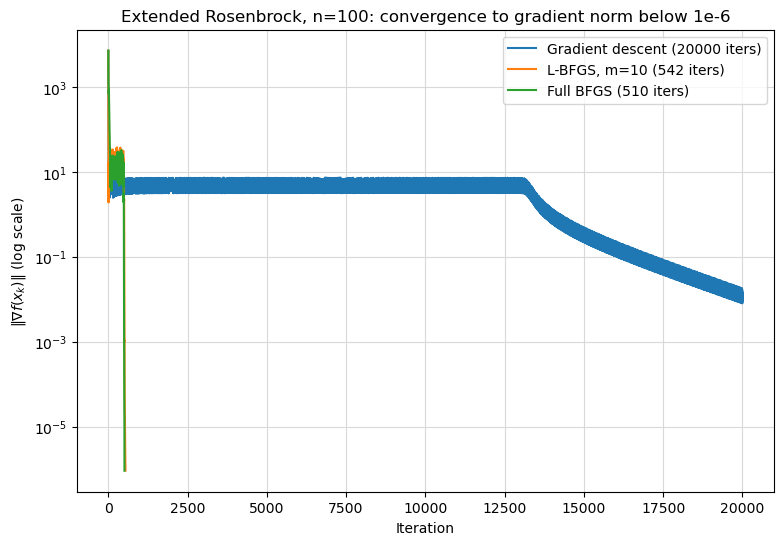

In [3]:
def gradient_descent(f, grad, x0, tol=1e-6, max_iter=20000):
    x = x0.copy()
    fx = f(x); gx = grad(x)
    history = [np.linalg.norm(gx)]
    k = 0
    for k in range(max_iter):
        if np.linalg.norm(gx) < tol:
            break
        p = -gx
        alpha, x, fx, gx = backtracking_wolfe(f, grad, x, p, fx, gx, alpha0=1.0)
        history.append(np.linalg.norm(gx))
    return x, fx, np.array(history), k + 1


def bfgs_full(f, grad, x0, tol=1e-6, max_iter=2000):
    n = len(x0)
    x = x0.copy()
    fx = f(x); gx = grad(x)
    H = np.eye(n)
    history = [np.linalg.norm(gx)]
    k = 0
    for k in range(max_iter):
        if np.linalg.norm(gx) < tol:
            break
        p = -H @ gx
        alpha, x_new, f_new, g_new = backtracking_wolfe(f, grad, x, p, fx, gx)
        s = x_new - x
        y = g_new - gx
        sy = s @ y
        if sy > 1e-10:
            rho = 1.0 / sy
            I = np.eye(n)
            H = (I - rho * np.outer(s, y)) @ H @ (I - rho * np.outer(y, s)) + rho * np.outer(s, s)
        x, fx, gx = x_new, f_new, g_new
        history.append(np.linalg.norm(gx))
    return x, fx, np.array(history), k + 1


n_dim = 100
x0 = np.empty(n_dim)
x0[0::2] = -1.2
x0[1::2] = 1.0
x_star = np.ones(n_dim)

x_gd, f_gd, hist_gd, it_gd = gradient_descent(rosenbrock, rosenbrock_grad, x0, tol=1e-6, max_iter=20000)
x_lb, f_lb, hist_lb, it_lb = lbfgs(rosenbrock, rosenbrock_grad, x0, m=10, tol=1e-6, max_iter=2000)
x_bf, f_bf, hist_bf, it_bf = bfgs_full(rosenbrock, rosenbrock_grad, x0, tol=1e-6, max_iter=2000)

print(f"Gradient descent: {it_gd} iters, final |grad|={hist_gd[-1]:.3e}, ||x-x*||={np.linalg.norm(x_gd-x_star):.3e}")
print(f"L-BFGS (m=10):    {it_lb} iters, final |grad|={hist_lb[-1]:.3e}, ||x-x*||={np.linalg.norm(x_lb-x_star):.3e}")
print(f"Full BFGS:        {it_bf} iters, final |grad|={hist_bf[-1]:.3e}, ||x-x*||={np.linalg.norm(x_bf-x_star):.3e}")

fig, ax = plt.subplots(figsize=(9, 6))
ax.semilogy(hist_gd, label=f"Gradient descent ({it_gd} iters)")
ax.semilogy(hist_lb, label=f"L-BFGS, m=10 ({it_lb} iters)")
ax.semilogy(hist_bf, label=f"Full BFGS ({it_bf} iters)")
ax.set_xlabel("Iteration")
ax.set_ylabel(r"$\|\nabla f(x_k)\|$ (log scale)")
ax.set_title(f"Extended Rosenbrock, n={n_dim}: convergence to gradient norm below 1e-6")
ax.legend()
ax.grid(True, which="both")
plt.savefig("lbfgs_rosenbrock_convergence.png", dpi=150, bbox_inches="tight")
plt.show()


## Notes

The gap is not just quantitative but qualitative: gradient descent exhausts its $20{,}000$-iteration
budget without reaching the $10^{-6}$ gradient-norm tolerance at all (it stalls at $\sim9.9\times
10^{-3}$, over three orders of magnitude short), while both quasi-Newton methods reach that
tolerance in roughly $500$ iterations — the Rosenbrock valley's curvature is severe enough that a
first-order method's step, however well line-searched, cannot rescale itself across the valley's
very different curvatures in different directions, and no amount of extra budget within a
practical range fixes that. L-BFGS and full BFGS track each other closely in iteration count
despite L-BFGS using only $m=10$ stored pairs (and $O(mn)=O(1000)$ floats of history) against full
BFGS's dense $n\times n=10{,}000$-entry matrix — the two-loop recursion is recovering essentially
the same curvature information the full inverse Hessian carries, at a fraction of the memory,
exactly the trade L-BFGS is designed to make. Both quasi-Newton runs land within $10^{-7}$ of
$x^\star=(1,\dots,1)$, consistent with superlinear local convergence once the iterates enter the
valley's neighborhood of the minimizer — a neighborhood gradient descent's stalled iterate has not
yet reached.